# Introducción básica al VRP

El VRP es una generalización del ya visto TSP. En su formulación más primitiva, son K los viajes que se deben hacer partiendo y luego llegando al depósito. Con este cambio, la nueva formulación queda como la siguiente:

Minimizar:
$$
\min \sum_{i=1}^{n} \sum_{\substack{j=1 \\ j \ne i}}^{n} c_{ij} x_{ij}
$$

Sujeto a:

$$
\sum_{\substack{i=2 \\ i \ne j}}^{n} x_{ij} = 1 \quad \text{para } j = 2, \dots, n;
$$

$$
\sum_{\substack{j=2 \\ j \ne i}}^{n} x_{ij} = 1 \quad \text{para } i = 2, \dots, n;
$$

$$
\sum_{\substack{i=2 }}^{n} x_{i1} = K
$$

$$
\sum_{\substack{j=2 }}^{n} x_{1j} = K
$$

$$
u_i - u_j + 1 \leq (n - 1)(1 - x_{ij}) \quad \text{para } 2 \leq i \neq j \leq n;
$$

$$
2<=u_{i}<=n   \quad \text{para } i = 2, \dots, n;
$$

$$
x_{ij} \in \{0, 1\} \quad \text{para } i, j = 1, \dots, n;
$$

Notese que en este aspecto, se le fuerza a hacer K viajes. Ya que no tiene la posibilidad de retornar en si mismo. Para poder hacer que sean K o menos viajes podemos plantear 2 estrategias.

La primera es declarar <= K en ambas ocasiones y forzar igualdad entre entradas y salidas.

La mejor, y más elegante, sería definir la sumatoria, no sobre j entre 2 y n, sino un conjunto de arcos saliente y entrantes del nodo principal. Al trabajar con el mismo es posible declarar si es posible un arco en si mismo o no.

En la teoría de grafos, estos arcos se suelen representar como:

$\delta(v)^-$ -> arcos entrantes a v

$\delta(v)^+$ -> arcos salientes de v

## Funciones útiles

En esta sección se definirán funciones que serán útiles a lo largo del notebook. Si no le interesa leer código, solo córralo.

In [1]:
#Importar librerias

import random
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import cdist
from ortools.linear_solver import pywraplp

load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\zlib1.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\abseil_dll.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\utf8_validity.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\re2.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\libprotobuf.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\highs.dll...
load c:\Users\josek\Desktop\ProyectosPersonales\InvestigacionOperativa\.venv\Lib\site-packages\ortools\.libs\ortools.dll...


In [2]:
def create_2d_points_df(n, seed):
  """
  Genera n puntos en un espacio 2D y los guarda en un dataframe de pandas.

  Args:
    n: número de puntos
    seed: semilla aleatoria usada para por hacer reproducible el código

  Returns:
    Un dataframe de Pandas con las columnas "x", e "y".
  """
  points_data = []
  random.seed(seed)
  for i in range(n):
    x = random.uniform(-100, 100)
    y = random.uniform(-100, 100)
    points_data.append({'x': x, 'y': y})

  df = pd.DataFrame(points_data)
  return df


def calculate_distance(df):
  """
 Toma un dataframe con columnas 'x' e 'y' y calcula las distancias euclídeas

  Args:
    df: dataframe de pandas con columnas 'x' e 'y'.

  Returns:
    Una matriz de distancias euclídeas.
  """
  coords = df[['x', 'y']].values
  distance_matrix = cdist(coords, coords, metric='euclidean')
  return distance_matrix

def plot_points(df):
  """
  Plotea los puntos generados por create_2d_points_df.

  Args:
    df: df: dataframe de pandas con columnas 'x' e 'y'.
  """
  x_coords = df['x'].tolist()
  y_coords = df['y'].tolist()

  plt.figure(figsize=(8, 8))
  plt.scatter(x_coords, y_coords)
  plt.title('Puntos en el espacio 2D')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.grid(True)
  plt.show()


def points_sub(points, i):
    """
    De una lista de numeros sustrae el numero i en una copia nueva.
    Se considera que poinla lista no tiene elementos duplicados (por ser lista de indices) y que i se encuentra en la lista.

    Args:
      points: lista de puntos.
      i: elemento a sustraer de la lista

    Returns:
      new: lista nueva similar a points pero sin el elemento i.
    """
    new = points.copy()
    new.remove(i)
    return new

Suponer que se tienen 10 puntos aleatorios en el espacio definidos a continuación:

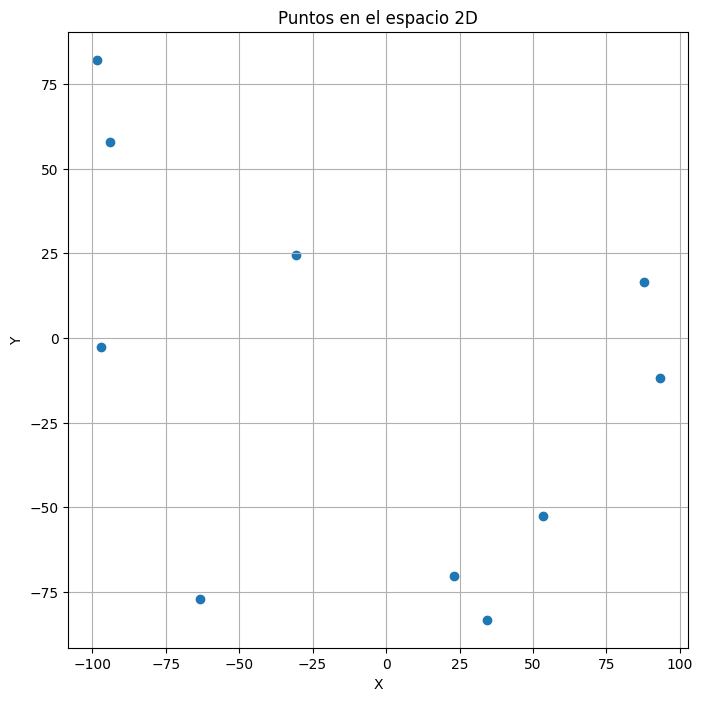

In [3]:
# Defino una semilla
seed = 1234

# Genero los puntos
puntos = create_2d_points_df(10, seed)

# Ploteo los puntos
plot_points(puntos)

# Calculo distancias
distancias = calculate_distance(puntos)

In [21]:
# Definimos el modelo
modelo_mtz = pywraplp.Solver.CreateSolver('SAT')
K=2
list_index_puntos = list(puntos.index)

# uso n como n-1 ya que arranco de indice 0 en la lista. Por esto en mtz no resto 1 ni en u_i
n = max(list_index_puntos)

# Definimos variables

x_ij={i:{j: modelo_mtz.IntVar(0,1,'x_'+str(i)+'_'+str(j)) for j in points_sub(list_index_puntos, i)} for i in list_index_puntos}
u_i = {i: modelo_mtz.IntVar(1,n,'u_'+str(i)) for i in points_sub(list_index_puntos, 0)}

# Definimos la función objetivo
obj_expr = sum(x_ij[i][j] * distancias[i][j] for i in list_index_puntos for j in points_sub(list_index_puntos, i))


#Restricciones:

#1
for j in points_sub(list_index_puntos, 0):
    modelo_mtz.Add(sum(x_ij[i][j] for i in points_sub(list_index_puntos, j)) == 1)

#2
for i in points_sub(list_index_puntos, 0):
    modelo_mtz.Add(sum(x_ij[i][j] for j in points_sub(list_index_puntos, i)) == 1)

#3
modelo_mtz.Add(sum(x_ij[0][j] for j in points_sub(list_index_puntos, 0)) == K)


#4
modelo_mtz.Add(sum(x_ij[i][0] for i in points_sub(list_index_puntos, 0)) == K)

#5
for i in points_sub(list_index_puntos, 0):
    for j in points_sub(points_sub(list_index_puntos, 0), i):
        modelo_mtz.Add(u_i[i] - u_i[j] + 1 <= n * (1- x_ij[i][j]))


# Solver
modelo_mtz.Minimize(obj_expr)

In [22]:
# Llamamos al solver
status = modelo_mtz.Solve()

In [23]:
if status == pywraplp.Solver.OPTIMAL:
    print("Costo total:", modelo_mtz.Objective().Value())
else:
    print("No se encontró solución óptima.")

Costo total: 639.930671909854


In [24]:
for i in list_index_puntos:
    print("Rutas desde el punto ", i, ":")
    for j in points_sub(list_index_puntos, i):  
        if x_ij[i][j].solution_value() > 0.5:
            print("  Hacia el punto ", j)

Rutas desde el punto  0 :
  Hacia el punto  2
  Hacia el punto  6
Rutas desde el punto  1 :
  Hacia el punto  5
Rutas desde el punto  2 :
  Hacia el punto  0
Rutas desde el punto  3 :
  Hacia el punto  4
Rutas desde el punto  4 :
  Hacia el punto  0
Rutas desde el punto  5 :
  Hacia el punto  9
Rutas desde el punto  6 :
  Hacia el punto  1
Rutas desde el punto  7 :
  Hacia el punto  3
Rutas desde el punto  8 :
  Hacia el punto  7
Rutas desde el punto  9 :
  Hacia el punto  8


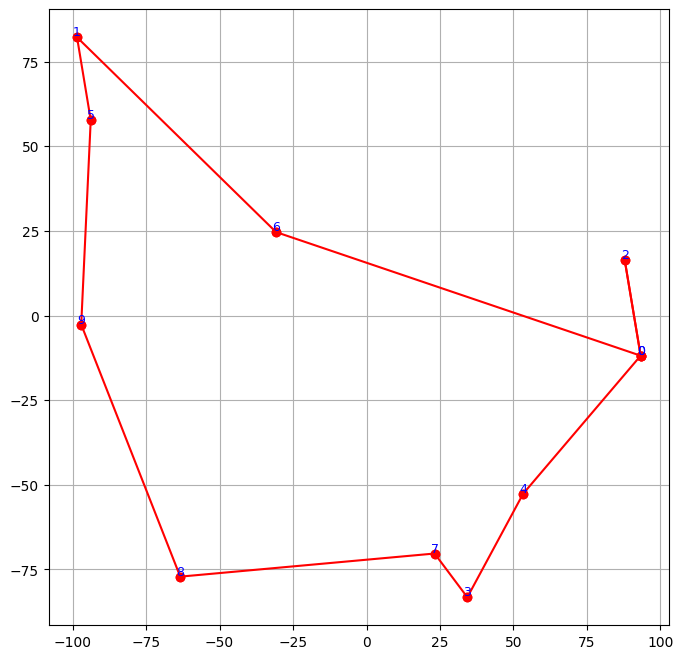

In [25]:
plt.figure(figsize=(8, 8))
plt.grid(True)
for i in list_index_puntos:
    for j in points_sub(list_index_puntos, i):
        if x_ij[i][j].SolutionValue() == 1:
            plt.plot(puntos.iloc[[i,j]]['x'], puntos.iloc[[i,j]]['y'], 'ro-')
            plt.text(puntos.iloc[i]['x'], puntos.iloc[i]['y'] + 0.5, str(i), ha='center', fontsize=9, color='blue')    
plt.show()

Vemos que en este caso tiene un ruta solo ida y vuelta a 2. Tal vez, si le damos flexibilidad, no sería necesaria y optaría por un solo viaje. Para esto, deberíamos reformular la formulación en python para poder contemplar los conjuntos de arcos que entran y salen de cada nodo. Esto se planteará más adelante